# CFPB Complaint Routing — Phase 3: Fine-tuned Transformer Router
**Question:** does a pretrained transformer beat the TF-IDF + Linear SVM baseline from Phase 2 (test macro-F1 **0.781**), and does it rely less on company names?

Plan:
1. Same data, same tidy-up, same **time-based split** as Phase 2
2. Re-fit the Phase 2 baseline on the *same* training window so the comparison is apples-to-apples
3. Fine-tune **DistilRoBERTa** (82M params) with class-weighted loss, mixed precision and length-bucketed batches
4. Compare on the untouched test window — overall, per team, and on the hardest confusion (debt collection vs credit reporting)
5. **Shortcut test:** mask company names in the test narratives and see which model's accuracy collapses
6. Confidence-based routing: how much can be auto-routed at ≥95% accuracy?

Runs on **Kaggle Notebooks** with a **GPU (T4 or P100)** and Internet on. Self-contained: it rebuilds the Phase 1 sample from the archived Hugging Face snapshot with the same seed.

## 1. Setup

In [1]:
import os, re, time, json, gc, math, random, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 300)
SEED = 42
OUT_DIR = "/kaggle/working"
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE, "| GPUs:", torch.cuda.device_count(),
      "|", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "no GPU - turn on an accelerator in Settings")

device: cuda | GPUs: 2 | Tesla T4


## 2. Data — identical to Phase 2

In [2]:
import glob
cached = glob.glob("/kaggle/input/**/cfpb_sample.parquet", recursive=True)
if cached:
    df = pd.read_parquet(cached[0]); print("loaded cached sample:", cached[0])
else:
    from huggingface_hub import hf_hub_download
    import pyarrow.parquet as pq
    PQ = hf_hub_download("vivekkopthsd/cfpb-consumer-complaints", "complaints.parquet",
                         repo_type="dataset", local_dir="/kaggle/temp")
    pf = pq.ParquetFile(PQ)
    COLS = ["date_received", "product", "sub_product", "issue", "sub_issue", "narrative",
            "company", "state", "company_response", "timely_response", "complaint_id"]
    START = pd.Timestamp("2020-01-01"); parts = []
    for batch in pf.iter_batches(batch_size=250_000, columns=COLS):
        chunk = batch.to_pandas()
        chunk["date_received"] = pd.to_datetime(chunk["date_received"], errors="coerce")
        chunk = chunk[chunk["narrative"].notna() & (chunk["narrative"].str.len() > 0)]
        chunk = chunk[chunk["date_received"] >= START]
        parts.append(chunk.sample(frac=0.15, random_state=SEED))
    df = pd.concat(parts, ignore_index=True); del parts; gc.collect()

    PRODUCT_MAP = {
        "Credit reporting, credit repair services, or other personal consumer reports": "Credit reporting",
        "Credit reporting or other personal consumer reports": "Credit reporting",
        "Credit reporting": "Credit reporting",
        "Debt collection": "Debt collection", "Debt or credit management": "Debt collection",
        "Credit card or prepaid card": "Credit card", "Credit card": "Credit card",
        "Prepaid card": "Prepaid / money transfer",
        "Money transfer, virtual currency, or money service": "Prepaid / money transfer",
        "Money transfers": "Prepaid / money transfer", "Virtual currency": "Prepaid / money transfer",
        "Checking or savings account": "Bank account", "Bank account or service": "Bank account",
        "Mortgage": "Mortgage", "Vehicle loan or lease": "Vehicle loan", "Consumer Loan": "Vehicle loan",
        "Student loan": "Student loan",
        "Payday loan, title loan, or personal loan": "Personal / payday loan",
        "Payday loan, title loan, personal loan, or advance loan": "Personal / payday loan",
        "Payday loan": "Personal / payday loan",
    }
    df["team"] = df["product"].map(PRODUCT_MAP).fillna("Other")

    def clean_text(s):
        s = re.sub(r"X{2,}/X{2,}/(X{2,}|\d{2,4})", " ", s)
        s = re.sub(r"\bX{2,}\b", " ", s)
        s = re.sub(r"\{\$[\d,.]+\}", " <amount> ", s)
        return re.sub(r"\s+", " ", s).strip()
    df["text"] = df["narrative"].map(clean_text)
    df["n_words"] = df["text"].str.split().str.len()
    df = df.drop_duplicates(subset="text")
    df = df[df["n_words"] >= 10].drop(columns="narrative").reset_index(drop=True)
    df.to_parquet(f"{OUT_DIR}/cfpb_sample.parquet", index=False)
print(df.shape)
print(df["team"].value_counts())

complaints.parquet: reconstructing file:   0%|          |  0.00B / 1.02GB            

complaints.parquet: downloading bytes:           |  0.00B            

(341860, 13)
team
Credit reporting            205598
Debt collection              42385
Credit card                  25827
Bank account                 24440
Prepaid / money transfer     14812
Mortgage                     12500
Vehicle loan                  6558
Student loan                  5555
Personal / payday loan        4185
Name: count, dtype: int64


In [3]:
def tidy(s):
    s = re.sub(r"/?\s*/?year>", " ", s)            # leftover 'XX/XX/year>' fragments
    s = re.sub(r"(?:\s*[,/;:]\s*){2,}", ", ", s)     # runs of punctuation left by removed redactions
    s = re.sub(r"\(\s*[,\s]*\)", " ", s)             # empty parentheses
    s = re.sub(r"^\s*(On|on)\s*,\s*", "", s)          # 'On , I ...' -> 'I ...'
    s = re.sub(r"\s+([,.;:!?])", r"\1", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()

before = df["text"].iloc[0]
df["text"] = df["text"].map(tidy)
print("BEFORE:", before[:200]); print("AFTER: ", df["text"].iloc[0][:200])
n0 = len(df)
df = df.drop_duplicates(subset="text").reset_index(drop=True)
print(f"\nrows: {n0:,} -> {len(df):,} after re-dedup")

BEFORE: On , resolved 7 disputes in my favor. <amount> was credited to my balance. The remaining <amount> , across 5 payouts ( Payout IDs , , , , ), was never received. states these funds were sent to my Send
AFTER:  resolved 7 disputes in my favor. <amount> was credited to my balance. The remaining <amount>, across 5 payouts ( Payout IDs, ), was never received. states these funds were sent to my Send Account on o

rows: 341,860 -> 340,347 after re-dedup


In [4]:
TRAIN_END, VAL_END = "2024-12-31", "2025-06-30"
train = df[df.date_received <= TRAIN_END]
val   = df[(df.date_received > TRAIN_END) & (df.date_received <= VAL_END)]
test  = df[df.date_received > VAL_END]
TEAMS = sorted(df["team"].unique())

split_dist = pd.DataFrame({name: d["team"].value_counts(normalize=True) for name, d in
                           [("train", train), ("val", val), ("test", test)]}).loc[TEAMS]
print({name: len(d) for name, d in [("train", train), ("val", val), ("test", test)]})
(split_dist * 100).round(1)

{'train': 219906, 'val': 59895, 'test': 60546}


,train,val,test
team,,,
Bank account,6.6,6.4,9.9
Credit card,7.8,4.8,9.4
Credit reporting,61.9,65.1,47.7
Debt collection,11.8,9.9,17.4
Mortgage,4.3,1.7,3.4
Personal / payday loan,1.2,0.8,1.9
Prepaid / money transfer,3.0,8.1,5.7
Student loan,1.6,1.7,1.7
Vehicle loan,1.9,1.3,2.8


## 3. Company-name masking (for the shortcut test)
Phase 2 showed the baseline's top features include company names (Equifax, Chime, Synchrony, Coinbase, Mohela, ...). That works, but it is a shortcut: a router should understand the *problem*, not just *who* it's about.
We build a list of brand tokens from the most frequent companies plus well-known brands, and replace them with `[COMPANY]`. Models are trained on normal text; masking is applied **only at test time** to measure how much each model depends on names.

In [5]:
GENERIC = set("""bank banks national financial financials services service group holdings holding inc llc corp corporation company co
the of and na n.a. usa us america american first credit card cards capital one trust union federal mortgage loan loans home
lending servicing solutions information management partners associates recovery collection collections systems consumer
technologies technology payments payment fund funding auto north south west east new city community savings""".split())
BRANDS = """equifax experian transunion lexisnexis chime synchrony discover barclays comenity citi citibank citigroup mastercard visa
amex paypal venmo zelle cashapp coinbase binance gemini kraken robinhood square block wise affirm klarna upstart netcredit
greensky acima mohela navient nelnet aidvantage edfinancial fedloan sallie santander bridgecrest carvana ally toyota honda bmw
wells fargo chase jpmorgan pnc truist regions huntington ocwen loancare newrez pennymac rocket mr cooper caliber midland
portfolio resurgent lvnv cavalry encore jefferson capital webbank goldman marcus apple sofi lendingclub navy usaa""".split()
top_companies = df["company"].value_counts().head(150).index
tokens = set(BRANDS)
for comp in top_companies:
    for w in re.findall(r"[a-z]+", comp.lower()):
        if len(w) > 2 and w not in GENERIC:
            tokens.add(w)
tokens -= {"capital", "one", "bank", "credit"}          # too generic to mask safely
pattern = re.compile(r"\b(" + "|".join(sorted(map(re.escape, tokens), key=len, reverse=True)) + r")\b", re.I)
mask_companies = lambda s: pattern.sub("[COMPANY]", s)
print(len(tokens), "brand tokens, e.g.", sorted(tokens)[:25])
ex = test["text"].iloc[3]
print("\nBEFORE:", ex[:300]); print("AFTER: ", mask_companies(ex)[:300])
test_masked_text = test["text"].map(mask_companies)
print(f"\ntest narratives containing at least one masked name: {(test_masked_text != test['text']).mean():.1%}")

218 brand tokens, e.g. ['acceptance', 'account', 'acima', 'adjusters', 'aes', 'affirm', 'afni', 'aid', 'aidvantage', 'aldous', 'ally', 'amerisave', 'amex', 'amsher', 'analytics', 'apple', 'asset', 'association', 'atlanticus', 'attorney', 'automobile', 'avant', 'avenue', 'bancorp', 'barclays']

BEFORE: Please See CFPB Record Complaint. repeatedly responded with FALSE information, as I have successfully proven with attachments of my loan history with, yet they STILL denied it.. yet Aidvantage provided an email stating the loan was received from.. which is their proof as well. This reported complain
AFTER:  Please See CFPB Record Complaint. repeatedly responded [COMPANY] FALSE information, as I have successfully proven [COMPANY] attachments of my loan history [COMPANY], yet they STILL denied it.. yet [COMPANY] provided an email stating the loan was received from.. which is their proof as well. This rep

test narratives containing at least one masked name: 91.5%


## 4. Baseline re-fit on the same training window
Phase 2's headline number (0.781) came from a model refit on train **+ validation**. Here both models see **only the 2020–2024 training window**, so the comparison is fair.

In [6]:
t0 = time.time()
TFIDF_KW = dict(ngram_range=(1, 2), min_df=10, max_df=0.9, sublinear_tf=True,
                max_features=200_000, strip_accents="unicode", dtype=np.float32)
vec = TfidfVectorizer(**TFIDF_KW)
X_tr = vec.fit_transform(train["text"])
svm = LinearSVC(C=0.25, class_weight="balanced").fit(X_tr, train["team"])
del X_tr; gc.collect()
y_va, y_te = val["team"].values, test["team"].values
svm_val  = svm.predict(vec.transform(val["text"]))
svm_scores = svm.decision_function(vec.transform(test["text"]))
svm_test = svm.classes_[svm_scores.argmax(1)]
svm_mask = svm.predict(vec.transform(test_masked_text))
print(f"baseline fit+predict {time.time()-t0:.0f}s")
for name, y, p in [("val", y_va, svm_val), ("test", y_te, svm_test), ("test (names masked)", y_te, svm_mask)]:
    print(f"TF-IDF+SVM {name:20s} macro-F1 {f1_score(y, p, average='macro'):.3f}  acc {accuracy_score(y, p):.3f}")

baseline fit+predict 271s
TF-IDF+SVM val                  macro-F1 0.752  acc 0.871
TF-IDF+SVM test                 macro-F1 0.773  acc 0.834
TF-IDF+SVM test (names masked)  macro-F1 0.723  acc 0.805


## 5. Tokenise for the transformer
- **DistilRoBERTa** keeps casing and punctuation and was pretrained on web text, a good fit for informal complaint narratives
- `MAX_LEN = 256` tokens covers the median complaint (~126 words) comfortably; ~10% of long narratives are truncated (Phase 1 finding)

In [7]:
MODEL_NAME, MAX_LEN = "distilroberta-base", 256
TEAMS = sorted(df["team"].unique()); label2id = {t: i for i, t in enumerate(TEAMS)}
tok = AutoTokenizer.from_pretrained(MODEL_NAME)

def encode(texts, bs=4096):
    ids = []
    for i in range(0, len(texts), bs):
        enc = tok(list(texts[i:i + bs]), truncation=True, max_length=MAX_LEN, add_special_tokens=True)
        ids.extend(np.asarray(x, dtype=np.int32) for x in enc["input_ids"])
    return ids

t0 = time.time()
ids_tr, ids_va = encode(train["text"].values), encode(val["text"].values)
ids_te, ids_tm = encode(test["text"].values), encode(test_masked_text.values)
lab_tr = train["team"].map(label2id).values
lens = np.array([len(x) for x in ids_tr])
print(f"tokenised in {time.time()-t0:.0f}s | median len {np.median(lens):.0f} | truncated at {MAX_LEN}: {(lens >= MAX_LEN).mean():.1%}")

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

tokenised in 100s | median len 138 | truncated at 256: 25.3%


## 6. Fine-tuning loop
Written as a plain PyTorch loop so every step is visible:
- **class-weighted cross-entropy** (weights ∝ 1/√frequency) — softer than fully balanced weights, so the 60% credit-reporting class isn't over-penalised
- **length-bucketed batches**: similar-length narratives are batched together, cutting padding (and GPU time) substantially
- **mixed precision** (fp16), AdamW, linear warm-up/decay, gradient clipping
- evaluate on the validation window after every epoch and keep the best checkpoint

In [8]:
PAD = tok.pad_token_id
def batches(ids, bs, shuffle):
    idx = np.arange(len(ids))
    if shuffle:
        np.random.shuffle(idx)
        chunks = [idx[i:i + bs * 50] for i in range(0, len(idx), bs * 50)]   # sort within chunks of 50 batches
        idx = np.concatenate([c[np.argsort([len(ids[j]) for j in c])] for c in chunks])
        out = [idx[i:i + bs] for i in range(0, len(idx), bs)]; random.shuffle(out); return out
    idx = idx[np.argsort([len(x) for x in ids])]                            # inference: fully sorted
    return [idx[i:i + bs] for i in range(0, len(idx), bs)]

def collate(ids, b):
    m = max(len(ids[j]) for j in b)
    x = np.full((len(b), m), PAD, dtype=np.int64); att = np.zeros((len(b), m), dtype=np.int64)
    for r, j in enumerate(b):
        x[r, :len(ids[j])] = ids[j]; att[r, :len(ids[j])] = 1
    return torch.from_numpy(x).to(DEVICE), torch.from_numpy(att).to(DEVICE)

@torch.no_grad()
def predict_proba(model, ids, bs=256):
    model.eval(); out = np.zeros((len(ids), len(TEAMS)), dtype=np.float32)
    for b in batches(ids, bs, shuffle=False):
        x, att = collate(ids, b)
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=DEVICE == "cuda"):
            logits = model(input_ids=x, attention_mask=att).logits
        out[b] = torch.softmax(logits.float(), -1).cpu().numpy()
    return out

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(TEAMS), id2label=dict(enumerate(TEAMS)), label2id=label2id).to(DEVICE)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
core = model.module if isinstance(model, nn.DataParallel) else model

EPOCHS, BS, LR = 2, 32, 3e-5
freq = np.bincount(lab_tr, minlength=len(TEAMS)) / len(lab_tr)
w = 1 / np.sqrt(freq); w = w / (w * freq).sum()
loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32, device=DEVICE))
print("class weights:", dict(zip(TEAMS, w.round(2))))

opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
steps_per_epoch = math.ceil(len(ids_tr) / BS)
sched = get_linear_schedule_with_warmup(opt, int(0.06 * EPOCHS * steps_per_epoch), EPOCHS * steps_per_epoch)
scaler = torch.amp.GradScaler("cuda", enabled=DEVICE == "cuda")
history, best_f1, best_state = [], -1, None
lab_tr_t = torch.tensor(lab_tr, dtype=torch.long)

for epoch in range(1, EPOCHS + 1):
    model.train(); t0 = time.time(); run_loss = 0
    for step, b in enumerate(batches(ids_tr, BS, shuffle=True), 1):
        x, att = collate(ids_tr, b); y = lab_tr_t[b].to(DEVICE)
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=DEVICE == "cuda"):
            loss = loss_fn(model(input_ids=x, attention_mask=att).logits.float(), y)
        opt.zero_grad(set_to_none=True)
        scaler.scale(loss).backward(); scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt); scaler.update(); sched.step()
        run_loss += loss.item()
        if step % 1000 == 0:
            print(f"  epoch {epoch} step {step}/{steps_per_epoch} loss {run_loss/step:.4f} ({time.time()-t0:.0f}s)")
    p_val = predict_proba(model, ids_va).argmax(1)
    f1 = f1_score(val["team"].map(label2id), p_val, average="macro")
    history.append({"epoch": epoch, "train_loss": run_loss / step, "val_macro_f1": f1, "minutes": (time.time() - t0) / 60})
    print(history[-1])
    if f1 > best_f1:
        best_f1 = f1; best_state = {k: v.detach().cpu().clone() for k, v in core.state_dict().items()}
core.load_state_dict(best_state)
pd.DataFrame(history)

model.safetensors: reconstructing file:   0%|          |  0.00B /  331MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


class weights: {'Bank account': np.float64(1.61), 'Credit card': np.float64(1.48), 'Credit reporting': np.float64(0.53), 'Debt collection': np.float64(1.21), 'Mortgage': np.float64(2.0), 'Personal / payday loan': np.float64(3.85), 'Prepaid / money transfer': np.float64(2.41), 'Student loan': np.float64(3.3), 'Vehicle loan': np.float64(3.04)}
  epoch 1 step 1000/6873 loss 1.0783 (154s)
  epoch 1 step 2000/6873 loss 0.8870 (307s)
  epoch 1 step 3000/6873 loss 0.7999 (458s)
  epoch 1 step 4000/6873 loss 0.7496 (609s)
  epoch 1 step 5000/6873 loss 0.7139 (761s)
  epoch 1 step 6000/6873 loss 0.6872 (912s)
{'epoch': 1, 'train_loss': 0.6694905902010401, 'val_macro_f1': 0.7549234264889794, 'minutes': 18.02972584962845}
  epoch 2 step 1000/6873 loss 0.4797 (151s)
  epoch 2 step 2000/6873 loss 0.4781 (304s)
  epoch 2 step 3000/6873 loss 0.4756 (455s)
  epoch 2 step 4000/6873 loss 0.4731 (606s)
  epoch 2 step 5000/6873 loss 0.4703 (758s)
  epoch 2 step 6000/6873 loss 0.4679 (909s)
{'epoch': 2, 't

,epoch,train_loss,val_macro_f1,minutes
0,1,0.669491,0.754923,18.029726
1,2,0.464533,0.768946,17.970031


## 7. Test-window comparison

In [9]:
P_te = predict_proba(model, ids_te); P_tm = predict_proba(model, ids_tm)
tr_test = np.array(TEAMS)[P_te.argmax(1)]; tr_mask = np.array(TEAMS)[P_tm.argmax(1)]
tr_val = np.array(TEAMS)[predict_proba(model, ids_va).argmax(1)]

def row(name, y, p): return {"model": name, "macro_f1": f1_score(y, p, average="macro"),
                             "weighted_f1": f1_score(y, p, average="weighted"), "accuracy": accuracy_score(y, p)}
comp = pd.DataFrame([
    row("TF-IDF + SVM | val", y_va, svm_val), row("DistilRoBERTa | val", y_va, tr_val),
    row("TF-IDF + SVM | test", y_te, svm_test), row("DistilRoBERTa | test", y_te, tr_test),
    row("TF-IDF + SVM | test, names masked", y_te, svm_mask), row("DistilRoBERTa | test, names masked", y_te, tr_mask),
]).set_index("model").round(3)
comp

,macro_f1,weighted_f1,accuracy
model,,,
TF-IDF + SVM | val,0.752,0.874,0.871
DistilRoBERTa | val,0.769,0.881,0.879
TF-IDF + SVM | test,0.773,0.831,0.834
DistilRoBERTa | test,0.791,0.843,0.844
"TF-IDF + SVM | test, names masked",0.723,0.801,0.805
"DistilRoBERTa | test, names masked",0.733,0.809,0.808


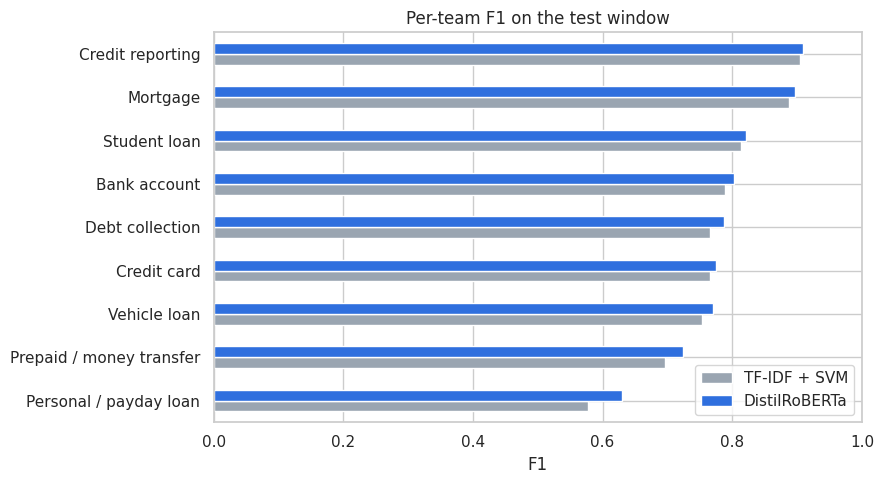

                          precision    recall  f1-score   support

            Bank account      0.803     0.803     0.803      6021
             Credit card      0.793     0.758     0.776      5718
        Credit reporting      0.888     0.930     0.908     28889
         Debt collection      0.826     0.751     0.787     10558
                Mortgage      0.893     0.901     0.897      2048
  Personal / payday loan      0.615     0.647     0.630      1149
Prepaid / money transfer      0.753     0.697     0.724      3430
            Student loan      0.819     0.823     0.821      1053
            Vehicle loan      0.763     0.778     0.770      1680

                accuracy                          0.844     60546
               macro avg      0.795     0.788     0.791     60546
            weighted avg      0.843     0.844     0.843     60546



,TF-IDF + SVM,DistilRoBERTa,test support,gain
Bank account,0.789,0.803,6021,0.014
Credit card,0.766,0.776,5718,0.010
Credit reporting,0.904,0.908,28889,0.004
Debt collection,0.765,0.787,10558,0.021
Mortgage,0.888,0.897,2048,0.010
Personal / payday loan,0.578,0.630,1149,0.053
Prepaid / money transfer,0.697,0.724,3430,0.027
Student loan,0.814,0.821,1053,0.008
Vehicle loan,0.753,0.770,1680,0.017


In [10]:
per_team = pd.DataFrame({
    "TF-IDF + SVM": f1_score(y_te, svm_test, average=None, labels=TEAMS),
    "DistilRoBERTa": f1_score(y_te, tr_test, average=None, labels=TEAMS),
    "test support": pd.Series(y_te).value_counts().reindex(TEAMS).values}, index=TEAMS)
per_team["gain"] = per_team["DistilRoBERTa"] - per_team["TF-IDF + SVM"]
fig, ax = plt.subplots(figsize=(9, 5))
per_team[["TF-IDF + SVM", "DistilRoBERTa"]].sort_values("DistilRoBERTa").plot.barh(ax=ax, color=["#9AA5B1", "#2F6FDE"])
ax.set(title="Per-team F1 on the test window", xlabel="F1"); ax.set_xlim(0, 1); plt.tight_layout(); plt.show()
print(classification_report(y_te, tr_test, digits=3))
per_team.round(3)

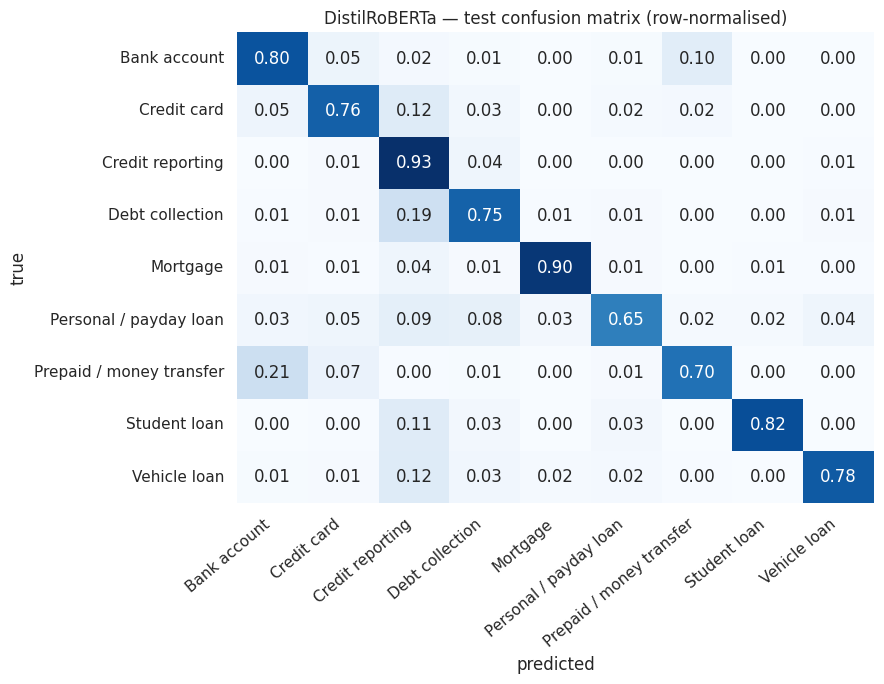

Debt collection -> Credit reporting errors:  SVM 2478 | DistilRoBERTa 2050
Prepaid/money transfer -> Bank account errors: SVM 835 | DistilRoBERTa 707


In [11]:
cm = confusion_matrix(y_te, tr_test, labels=TEAMS, normalize="true")
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=TEAMS, yticklabels=TEAMS, ax=ax, cbar=False)
ax.set(title="DistilRoBERTa — test confusion matrix (row-normalised)", xlabel="predicted", ylabel="true")
plt.xticks(rotation=40, ha="right"); plt.tight_layout(); plt.show()
pair = lambda p, a, b: int(((y_te == a) & (p == b)).sum())
print("Debt collection -> Credit reporting errors:  SVM", pair(svm_test, "Debt collection", "Credit reporting"),
      "| DistilRoBERTa", pair(tr_test, "Debt collection", "Credit reporting"))
print("Prepaid/money transfer -> Bank account errors: SVM", pair(svm_test, "Prepaid / money transfer", "Bank account"),
      "| DistilRoBERTa", pair(tr_test, "Prepaid / money transfer", "Bank account"))

## 8. Shortcut test — how much does each model rely on company names?
A large drop when names are masked means the model was leaning on *who* rather than *what*.

In [12]:
drop = pd.DataFrame({
    "test macro-F1": [comp.loc["TF-IDF + SVM | test", "macro_f1"], comp.loc["DistilRoBERTa | test", "macro_f1"]],
    "names masked":  [comp.loc["TF-IDF + SVM | test, names masked", "macro_f1"], comp.loc["DistilRoBERTa | test, names masked", "macro_f1"]],
}, index=["TF-IDF + SVM", "DistilRoBERTa"])
drop["drop"] = drop["test macro-F1"] - drop["names masked"]
drop["relative drop"] = (drop["drop"] / drop["test macro-F1"]).map("{:.1%}".format)
masked_rows = (test_masked_text != test["text"]).values
print(f"On the {masked_rows.mean():.0%} of test complaints that actually contained a name:")
for name, a, b in [("TF-IDF + SVM", svm_test, svm_mask), ("DistilRoBERTa", tr_test, tr_mask)]:
    print(f"  {name:14s} accuracy {accuracy_score(y_te[masked_rows], a[masked_rows]):.3f} -> "
          f"{accuracy_score(y_te[masked_rows], b[masked_rows]):.3f} with names masked")
drop.round(3)

On the 92% of test complaints that actually contained a name:
  TF-IDF + SVM   accuracy 0.836 -> 0.803 with names masked
  DistilRoBERTa  accuracy 0.847 -> 0.808 with names masked


,test macro-F1,names masked,drop,relative drop
TF-IDF + SVM,0.773,0.723,0.050,6.5%
DistilRoBERTa,0.791,0.733,0.058,7.3%


## 9. Confidence-based routing
DistilRoBERTa gives calibrated-ish probabilities; the SVM gives a decision margin. For each, find the largest share of complaints we can auto-route while keeping ≥95% accuracy on that share.

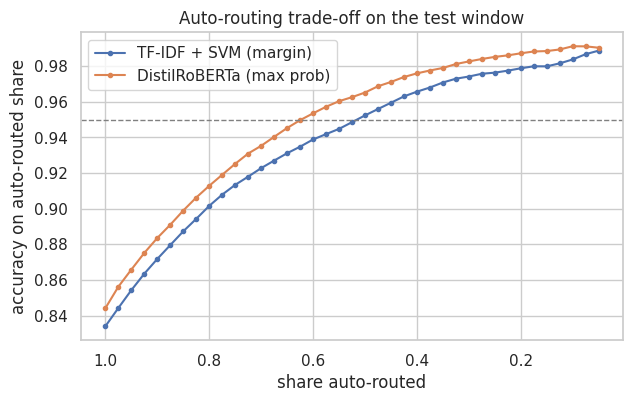

{'TF-IDF + SVM (margin)': '50% auto-routed at >=95% accuracy', 'DistilRoBERTa (max prob)': '60% auto-routed at >=95% accuracy'}


In [13]:
def coverage_curve(conf, correct):
    rows = []
    for q in np.linspace(0, 0.95, 39):
        keep = conf >= np.quantile(conf, q)
        rows.append({"coverage": keep.mean(), "accuracy": correct[keep].mean()})
    return pd.DataFrame(rows)
s = np.sort(svm_scores, 1)
curves = {"TF-IDF + SVM (margin)": coverage_curve(s[:, -1] - s[:, -2], svm_test == y_te),
          "DistilRoBERTa (max prob)": coverage_curve(P_te.max(1), tr_test == y_te)}
fig, ax = plt.subplots(figsize=(7, 4))
for name, c in curves.items(): ax.plot(c.coverage, c.accuracy, marker="o", ms=3, label=name)
ax.axhline(0.95, ls="--", c="grey", lw=1); ax.invert_xaxis(); ax.legend()
ax.set(title="Auto-routing trade-off on the test window", xlabel="share auto-routed", ylabel="accuracy on auto-routed share")
plt.show()
routing = {n: float(c[c.accuracy >= 0.95].coverage.max()) for n, c in curves.items()}
print({k: f"{v:.0%} auto-routed at >=95% accuracy" for k, v in routing.items()})

## 10. Where the transformer fixed the baseline's mistakes

In [14]:
fixed = test.assign(svm=svm_test, tr=tr_test)
fixed = fixed[(fixed.svm != fixed.team) & (fixed.tr == fixed.team)]
print(f"{len(fixed):,} test complaints fixed by the transformer; "
      f"{int(((svm_test == y_te) & (tr_test != y_te)).sum()):,} newly broken")
for _, r in fixed.sample(min(3, len(fixed)), random_state=SEED).iterrows():
    print(f"\n--- true: {r.team} | SVM said: {r.svm}\n{r.text[:350]}")

3,071 test complaints fixed by the transformer; 2,455 newly broken

--- true: Credit card | SVM said: Bank account
Discovercard, my statement closed with a balance of <amount> with a payment due date of. I prefer to not carry a large balance through the month so on I manually submitted an electronic payment of <amount> which was processed. The payment due on should therefore have been <amount>. I have paid down in the past to have a reduced payment had no reaso

--- true: Bank account | SVM said: Credit card
I rented a car from in using my Current account. The vehicle had unsafe tires, and tire blew out while I was driving. I returned the car and disputed several charges with Current ( approximately <amount> total for rental fees, gas, and late fees ). I provided photos showing the unsafe tire and explained that the charges were not valid because the c

--- true: Debt collection | SVM said: Credit reporting
HELVEY ASSO C is falsely reporting on my credit. I have never had any accounts 

## 11. Save the model and metrics

In [15]:
save_dir = f"{OUT_DIR}/distilroberta-cfpb-router"
core.save_pretrained(save_dir); tok.save_pretrained(save_dir)
metrics = {"phase": 3, "model": MODEL_NAME, "max_len": MAX_LEN, "epochs": EPOCHS, "lr": LR, "batch_size": BS,
           "train_window": "2020-01-01..2024-12-31", "val_window": "2025-01..2025-06", "test_window": "2025-07..2026-07",
           "history": history, "comparison": comp.reset_index().to_dict(orient="records"),
           "per_team_f1": per_team.round(4).reset_index().to_dict(orient="records"),
           "auto_route_coverage_at_95": routing}
json.dump(metrics, open(f"{OUT_DIR}/phase3_metrics.json", "w"), indent=2, default=float)
print(json.dumps(metrics["comparison"], indent=1, default=float)[:1500])

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[
 {
  "model": "TF-IDF + SVM | val",
  "macro_f1": 0.752,
  "weighted_f1": 0.874,
  "accuracy": 0.871
 },
 {
  "model": "DistilRoBERTa | val",
  "macro_f1": 0.769,
  "weighted_f1": 0.881,
  "accuracy": 0.879
 },
 {
  "model": "TF-IDF + SVM | test",
  "macro_f1": 0.773,
  "weighted_f1": 0.831,
  "accuracy": 0.834
 },
 {
  "model": "DistilRoBERTa | test",
  "macro_f1": 0.791,
  "weighted_f1": 0.843,
  "accuracy": 0.844
 },
 {
  "model": "TF-IDF + SVM | test, names masked",
  "macro_f1": 0.723,
  "weighted_f1": 0.801,
  "accuracy": 0.805
 },
 {
  "model": "DistilRoBERTa | test, names masked",
  "macro_f1": 0.733,
  "weighted_f1": 0.809,
  "accuracy": 0.808
 }
]


In [16]:
def route(narrative: str):
    p = predict_proba(model, encode([tidy(narrative)]))[0]; o = p.argsort()[::-1]
    return {"team": TEAMS[o[0]], "confidence": round(float(p[o[0]]), 3), "runner_up": TEAMS[o[1]]}
route("A collection agency keeps calling me about a debt I already paid, and now it shows up on my credit report.")

{'team': 'Debt collection',
 'confidence': 0.987,
 'runner_up': 'Credit reporting'}

## Findings & next steps
*(summarised in the README after the run)*
- **Phase 4:** trend detection — anomaly detection on monthly complaint volumes per team / issue / company, plus topic modelling for emerging issues.